# Semi-synthetic data generation with IHDP - 3-valued treatment
## Based on Vincent Dorie's NPCI's DGP from https://github.com/vdorie/npci

In [1]:
import sklearn
import numpy as np
import keras
import pandas as pd
import tensorflow as tf

### Read and process covariates

In [2]:
np.random.seed(3)

# Read
covar_file = '/home/bvelasco/PhD/Dragonnet/dragonnet/dat/ihdp/ihdp.csv'
covars = pd.read_csv(covar_file)
#covars.sample(frac=0.01)

# Augment data (replicate)
number_of_replications=15
covars = covars.loc[covars.index.repeat(number_of_replications)]
#covars = covars.sample(frac=1).reset_index(drop=True)
covars = covars.reset_index(drop=True)

# Drop unneeded
covars.drop(['Unnamed: 0'], axis=1, inplace=True)

# Fix 'first' var
covars['first'] = covars['first']-1

# Continuous vars
conts = ['bw', 'b.head', 'preterm', 'birth.o', 'nnhealth', 'momage']
# Binary vars
binar = [var for var in list(covars.columns.values) if var not in conts]

# Normalize continuous vars
for col in conts:
    covars[col] = (covars[col]-covars[col].mean())/covars[col].std()
    

### Distribution of example vars before adding noise

<AxesSubplot:>

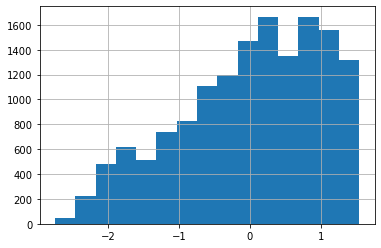

In [3]:
covars.bw.hist(bins=15)

<AxesSubplot:>

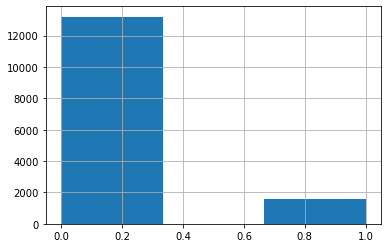

In [4]:
covars.momhisp.hist(bins=3)

In [5]:
# Add noise continuous vars
for col in conts:
    normal_noise = np.random.normal(0,0.8,len(covars))
    uniform_noise = np.random.uniform(-0.5,0.5,len(covars))
    covars[col] = covars[col] + uniform_noise


In [6]:
# Add noise to binary vars
for col in binar:
    binomial_noise = np.random.binomial(1, 0.2, len(covars))
    covars.loc[binomial_noise==0][col] = 1-covars.loc[binomial_noise==0,col]


/home/bvelasco/.conda/envs/python3.6/lib/python3.6/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


### Distribution of var bw after adding noise

<AxesSubplot:>

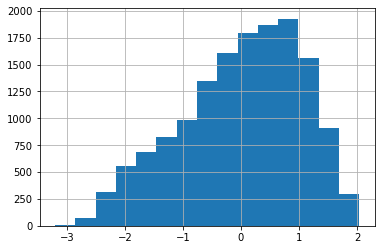

In [7]:
covars.bw.hist(bins=15)

<AxesSubplot:>

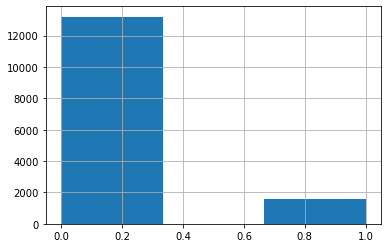

In [8]:
covars.momhisp.hist(bins=3)

### Treatment assignment and Response surfaces

In [9]:
# Paramters
t_vals = np.array([0,1,2]) # treatment options
beta_vals = np.arange(0.0, 0.5, 0.1) # beta values
beta_probs = np.array([0.7, 0.15, 0.1, 0.03, 0.02]) # beta probs
w = np.ones((covars.shape[0], covars.shape[1]-1))*0.5 # offset matrix 
sigma = 1 # std
num_reps = 70


temp_all = pd.DataFrame(columns=['bw', 'b.head', 'preterm', 'birth.o', 'nnhealth', 'momage', 'sex',
       'twin', 'b.marr', 'mom.lths', 'mom.hs', 'mom.scoll', 'cig', 'first',
       'booze', 'drugs', 'work.dur', 'prenatal', 'ark', 'ein', 'har', 'mia',
       'pen', 'tex', 'was', 'momwhite', 'momblack', 'momhisp', 'mu_0', 'mu_1',
       'mu_2', 'y_0', 'y_1', 'y_2', 'y', 'z'])

for i in range(num_reps):
    
    # Treatment assignment (probabilistic based on covariate, non-random)
    t_momblack = np.random.choice(t_vals, covars[covars.momblack==1].shape[0], replace=True, p=np.array([0.7, 0.15, 0.15]))
    t_momwhite = np.random.choice(t_vals, covars[covars.momwhite==1].shape[0], replace=True, p=np.array([0.15, 0.7, 0.15]))
    t_momhisp = np.random.choice(t_vals, covars[covars.momhisp==1].shape[0], replace=True, p=np.array([0.15, 0.15, 0.7]))

    covars.loc[(covars['momblack']==1), 'treat'] = t_momblack
    covars.loc[(covars['momwhite']==1), 'treat'] = t_momwhite
    covars.loc[(covars['momhisp']==1), 'treat'] = t_momhisp

    covars.reset_index(inplace=True, drop=True)
    z = covars['treat']
    covars.drop(['treat'], axis=1, inplace=True)
    covars_tab = covars.copy()
    #covars = covars.to_numpy()
    
    # Parameters  
    beta = np.random.choice(beta_vals, covars.shape[1], replace=True, p=beta_probs) # multiplying vector
    w = np.ones((covars.shape))*0.5 # offset matrix 

    # Response surface functions (function and sampling from distribution) 
    #print(sum(covars.momhisp))
    #print(sum(covars.to_numpy()[:,27]))
    f_0 = lambda x: np.exp(np.matmul((x + w),beta)) + 20*x[:,26] # additive term for displacing the mean of the normal distribution based on T
    f_1 = lambda x: np.log(np.abs(np.matmul(x,beta))+1e-10) + 60*x[:,25]
    f_2 = lambda x: np.matmul(x,beta) + 40*x[:,27]
    y_f = lambda x: np.random.normal(x, sigma)

    # Compute true effect
    covars_tab['mu_0'] = f_0(covars.to_numpy())
    covars_tab['mu_1'] = f_1(covars.to_numpy())
    covars_tab['mu_2'] = f_2(covars.to_numpy())

    # Sample from normal distribution
    covars_tab['y_0'] = y_f(covars_tab.mu_0)
    covars_tab['y_1'] = y_f(covars_tab.mu_1)
    covars_tab['y_2'] = y_f(covars_tab.mu_2)
    
    y = covars_tab.y_0.copy()
    y[z==0] = covars_tab.y_0[z==0].values
    y[z==1] = covars_tab.y_1[z==1].values
    y[z==2] = covars_tab.y_2[z==2].values

    covars_tab['y'] = y
    covars_tab['z'] = z.astype(int)
    
    temp_all = pd.concat([temp_all, covars_tab], axis=0)

    filename = '/home/bvelasco/PhD/Dragonnet/dragonnet/dat/ihdp/tri_case/reps_{}/ihdp_tri_{}.csv'.format(number_of_replications,i)
    covars_tab.to_csv(filename)
    

## Statistics

### Confounder proportions

In [10]:
print('Percentage of T==0: {}'.format(sum(temp_all['momhisp']==1)/len(temp_all)))
print('Percentage of T==1: {}'.format(sum(temp_all['momblack']==1)/len(temp_all)))
print('Percentage of T==2: {}'.format(sum(temp_all['momwhite']==1)/len(temp_all)))

Percentage of T==0: 0.1065989847715736
Percentage of T==1: 0.5248730964467005
Percentage of T==2: 0.36852791878172586


### Treatment proportions

In [11]:
print('Percentage of T==0: {}'.format(sum(temp_all['z']==0)/len(temp_all)))
print('Percentage of T==1: {}'.format(sum(temp_all['z']==1)/len(temp_all)))
print('Percentage of T==2: {}'.format(sum(temp_all['z']==2)/len(temp_all)))


Percentage of T==0: 0.438165820642978
Percentage of T==1: 0.3530510031423737
Percentage of T==2: 0.2087831762146483


### Mean values of the true effects

In [12]:
print('True average y_0: {}'.format(temp_all['y_0'].mean()))
print('True average y_1: {}'.format(temp_all['y_1'].mean()))
print('True average y_2: {}'.format(temp_all['y_2'].mean()))


True average y_0: 13.8488137630907
True average y_1: 20.84956233767676
True average y_2: 4.609122942066898


### Mean values of the biased effects

In [13]:
print('Biased average y0: {}'.format(temp_all.y[temp_all.z==0].mean()))
print('Biased average y1: {}'.format(temp_all.y[temp_all.z==1].mean()))
print('Biased average y2: {}'.format(temp_all.y[temp_all.z==2].mean()))


Biased average y0: 20.055342327276723
Biased average y1: 42.57252779214561
Biased average y2: 14.610073053787676
